## Paper plots: Forward Problems

## Setup

In [1]:
import torch
import numpy as np
import os

In [2]:
ROOT = "."
assert os.path.isfile(ROOT+"/forward_problems.ipynb")

In [3]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)
import matplotlib
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12 
lwthick = 5
lwthin = .5
linestyles = ["solid","dashed","dotted","dashdot"]

## Elliptic PDE 1D

In [4]:
pltdata_epde1d = torch.load(ROOT+"/in/data_final_plot.elliptic_pde_1d.pt",weights_only=True)
x_epde1d = pltdata_epde1d["x"]
u_v_epde1d = pltdata_epde1d["u_v"]
vs_v_epde1d = pltdata_epde1d["vs_v"]
data_Linvs_epde1d = pltdata_epde1d["data_Linvs"]

/tmp/ipykernel_1211927/2204710821.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  ax[0].plot(x_epde1d.cpu(),u_v_epde1d[r].T.cpu(),linewidth=lwthick,color="black")


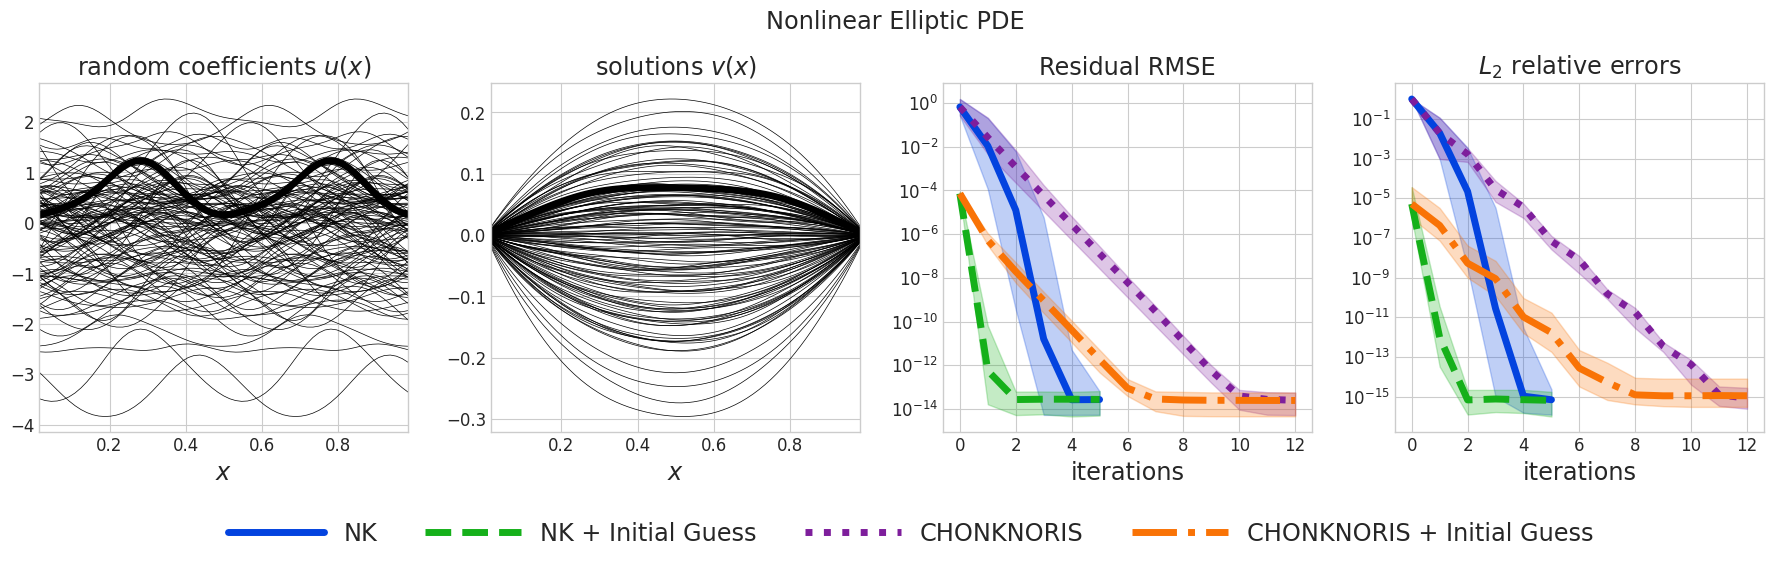

In [5]:
r = 0
fig,ax = pyplot.subplots(nrows=1,ncols=4,figsize=(4*4.5,5))
ax[0].plot(x_epde1d.cpu(),u_v_epde1d.T.cpu(),color="black",linewidth=lwthin)
ax[1].plot(x_epde1d.cpu(),vs_v_epde1d[:,-1,:].T.cpu(),color="black",linewidth=lwthin)
ax[0].plot(x_epde1d.cpu(),u_v_epde1d[r].T.cpu(),linewidth=lwthick,color="black")
ax[1].plot(x_epde1d.cpu(),vs_v_epde1d[r,-1,:].T.cpu(),linewidth=lwthick,color="black")
for j,(key,data_Linv) in enumerate(data_Linvs_epde1d.items()):
    # if "CHONKNORIS" not in key: continue
    for k,metric in enumerate(["rmse_resid","l2rerrors"]):
        medians = torch.quantile(data_Linv[metric],q=0.5,dim=0)
        iterrange = torch.arange(len(medians))
        ax[2+k].plot(iterrange,medians,linewidth=lwthick,color=COLORS[j],label=key,linestyle=linestyles[j])
        ax[2+k].fill_between(iterrange,
                        torch.quantile(data_Linv[metric],q=0.1,dim=0),
                        torch.quantile(data_Linv[metric],q=0.9,dim=0),
                        color = COLORS[j], 
                       alpha = 0.25)
for i in range(2):
    ax[i].set_xlim([x_epde1d.min().item(),x_epde1d.max().item()])
for i in range(2,4):
    ax[i].set_yscale("log",base=10)
ax[0].set_title(r"random coefficients $u(x)$",fontsize="xx-large")
ax[0].set_xlabel(r"$x$",fontsize="xx-large")
ax[1].set_title(r"solutions $v(x)$",fontsize="xx-large")
ax[1].set_xlabel(r"$x$",fontsize="xx-large")
ax[2].set_title("Residual RMSE",fontsize="xx-large")
ax[3].set_title(r"$L_2$ relative errors",fontsize="xx-large")
ax[2].set_xlabel(r"iterations",fontsize="xx-large")
ax[3].set_xlabel(r"iterations",fontsize="xx-large")
handles,labels = ax[2].get_legend_handles_labels()
legend = fig.legend(handles,labels,frameon=False,ncols=10,bbox_to_anchor=(.9,0),fontsize="xx-large",handlelength=4)
fig.suptitle("Nonlinear Elliptic PDE",fontsize="xx-large")
fig.tight_layout()
fig.savefig(ROOT+"/out/elliptic_pde_complete.png",bbox_inches="tight",dpi=256,transparent=True)

## Burgers Equation

In [6]:
pltdata_burgers = torch.load(ROOT+"/in/data_final_plot.burgers_1d.pt",weights_only=True)
xticks_b1d = pltdata_burgers["xticks"]
data_v_chonknoris_b1d = pltdata_burgers["data_v_chonknoris"]
tticks_b1d = pltdata_burgers["tticks"] 
xmesh_b1d = pltdata_burgers["xmesh"] 
tmesh_b1d = pltdata_burgers["tmesh"] 
data_v_nk_b1d = pltdata_burgers["data_v_nk"]

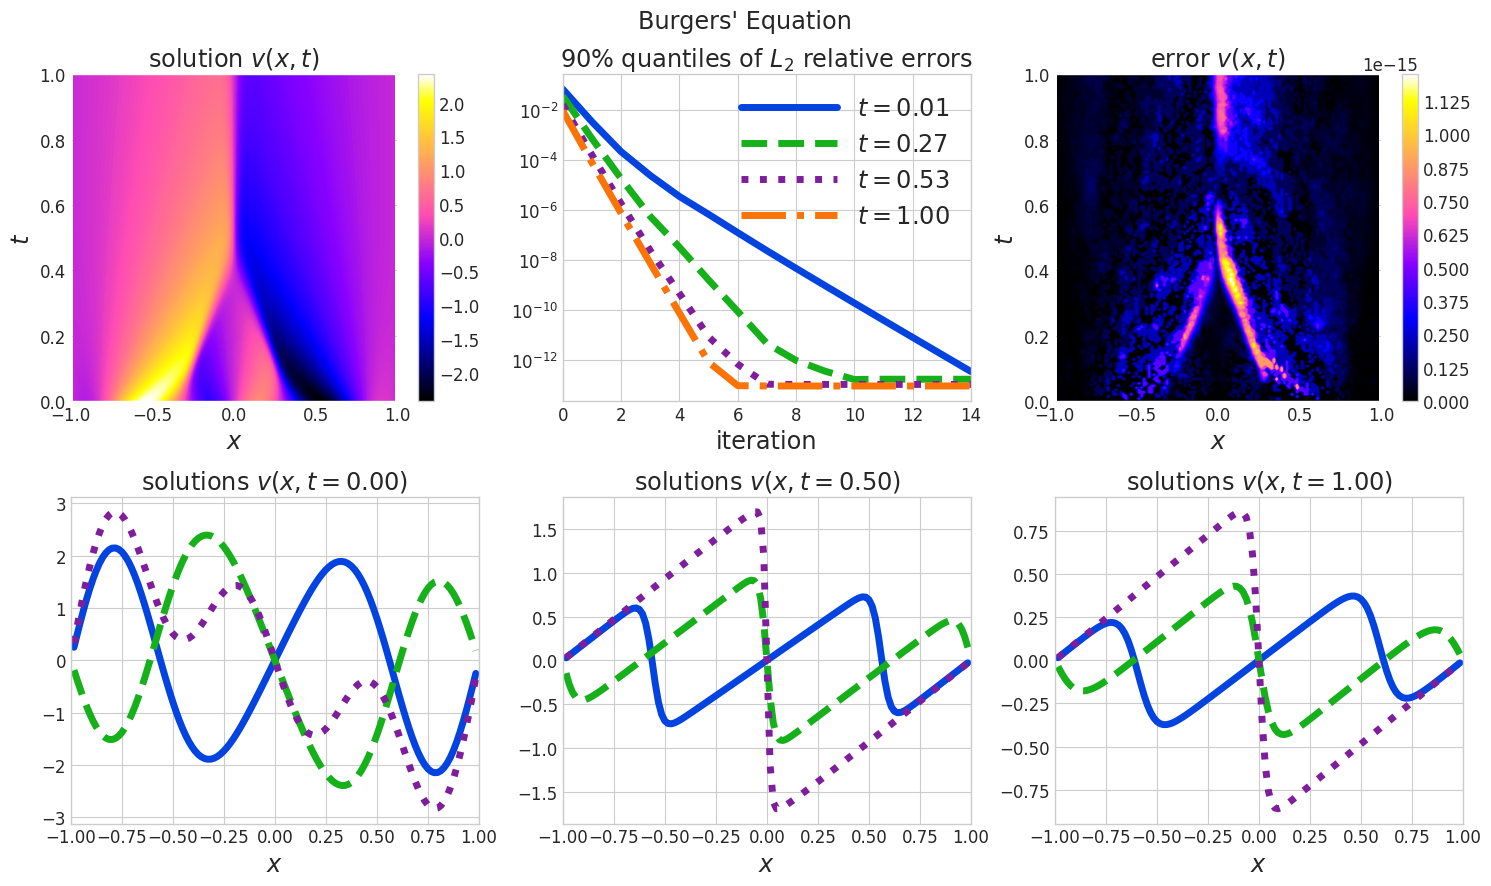

In [7]:
fig,ax = pyplot.subplots(nrows=2,ncols=3,figsize=(5*3,4.5*2),sharex=False,sharey=False)
tpltidxs = [0,75,150]
tquantiles = [1,40,80,150]
ridxs = [0,3,49]
itershow = 15
q = .9
rfull = 16
# ridxs = list(range(10))
for j,tidx in enumerate(tpltidxs):
    for k,r in enumerate(ridxs):
        ax[1,j].plot(xticks_b1d,data_v_chonknoris_b1d["MLP"]["vs"][r,tidx,-1],label=r,linewidth=lwthick,linestyle=linestyles[k])
    ax[1,j].set_title(r"solutions $v(x,t=%.2f)$"%tticks_b1d[tidx],fontsize="xx-large")
    ax[1,j].set_xlabel(r"$x$",fontsize="xx-large")
    ax[1,j].set_xlim([-1,1])
for j,tidx in enumerate(tquantiles):
    ax[0,1].plot(torch.arange(itershow),torch.quantile(data_v_chonknoris_b1d["MLP"]["l2rerrors"][:,tidx,:],q=q,dim=0)[:itershow],label=r"$t = %.2f$"%tticks_b1d[tidx],linewidth=lwthick,linestyle=linestyles[j])
ax[0,1].set_yscale("log",base=10)
ax[0,1].set_xlabel("iteration",fontsize="xx-large")
ax[0,1].set_title("%d%% quantiles of $L_2$ relative errors"%(100*q),fontsize="xx-large")
cf = ax[0,0].contourf(xmesh_b1d,tmesh_b1d,data_v_chonknoris_b1d["MLP"]["vs"][rfull,:,-1,:],cmap="gnuplot2",levels=250)
fig.colorbar(cf)
cf = ax[0,2].contourf(xmesh_b1d,tmesh_b1d,torch.abs(data_v_nk_b1d["vs"][rfull,:,-1,:]-data_v_chonknoris_b1d["MLP"]["vs"][rfull,:,-1,:]),cmap="gnuplot2",levels=250)
fig.colorbar(cf)
for j in [0,2]:
    ax[0,j].set_xlim([-1,1])
    ax[0,j].set_ylim([0,1])
    for spine in ["left","top","bottom","right"]:
        ax[0,j].spines[spine].set_color("white")#(False)
    ax[0,j].set_xlabel(r"$x$",fontsize="xx-large")
    ax[0,j].set_ylabel(r"$t$",fontsize="xx-large")
ax[0,0].set_title(r"solution $v(x,t)$",fontsize="xx-large")
ax[0,2].set_title(r"error $v(x,t)$",fontsize="xx-large")
ax[0,1].set_xlim([0,itershow-1])
ax[0,1].legend(fontsize="xx-large",facecolor="white",framealpha=0,frameon=True,handlelength=4)
fig.suptitle("Burgers' Equation",fontsize="xx-large")
fig.tight_layout()
fig.savefig("out/burgers_complete.png",bbox_inches="tight",dpi=256,transparent=True)

## Darcy 2d

In [8]:
pltdata_darcy = torch.load(ROOT+"/in/data_final_plot.darcy_2d.pt")
data_Linvs_dpde2d = pltdata_darcy["data_Linvs"]
x1mesh_dpde2d = pltdata_darcy["x1mesh"]
x2mesh_dpde2d = pltdata_darcy["x2mesh"]
v0hat_v_fastgp_dpde2d = pltdata_darcy["v0hat_v_fastgp"]
f_dpde2d = pltdata_darcy["f"]
u_v_dpde2d = pltdata_darcy["u_v"]

/tmp/ipykernel_1211927/93940719.py:46: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


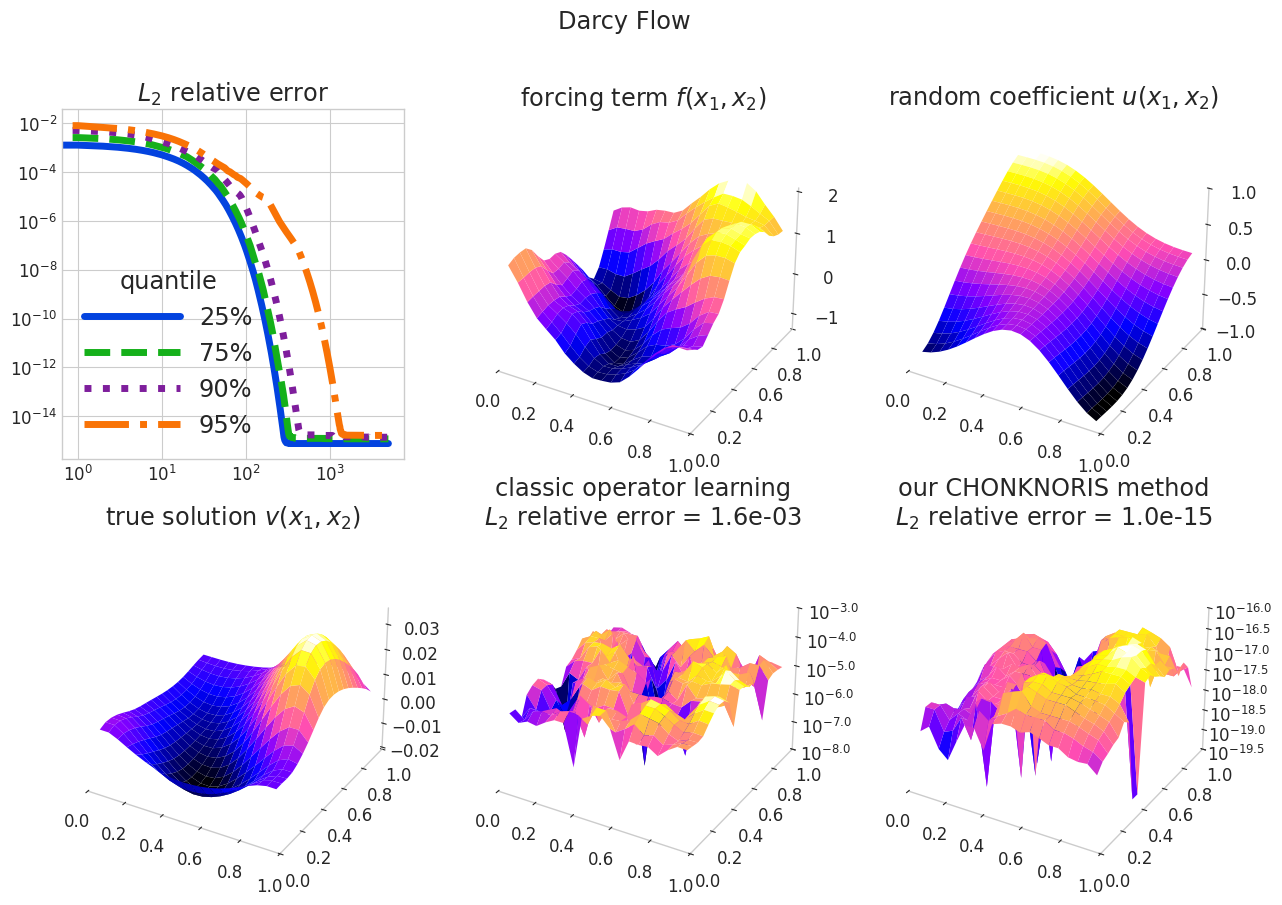

In [9]:
nrows = 2
ncols = 3
surfkwargs = {"rstride":1,"cstride":1,"cmap":"gnuplot2"}
fig = pyplot.figure(figsize=(5*ncols,5*nrows))
ax = np.array([[fig.add_subplot(nrows,ncols,i*ncols+j+1,projection=None if i==j==0 else "3d") for j in range(ncols)] for i in range(nrows)]).reshape((nrows,ncols))
data_Linv = data_Linvs_dpde2d["Fast GPR_lr_0.100000"]
data_ref = data_Linvs_dpde2d["reference"]
data_Linv["vs"].shape,data_ref["vs"].shape
r = 3
qs = [.25,.75,.9,.95]
for i,q in enumerate(qs):
    ax[0,0].plot(torch.arange(data_Linv["l2rerrors"].size(1)),torch.nanquantile(data_Linv["l2rerrors"],q=q,dim=0),linewidth=lwthick,linestyle=linestyles[i],label="%d%%"%(100*q))
ax[0,0].legend(fontsize="xx-large",title="quantile",title_fontsize="xx-large",handlelength=4)
ax[0,0].set_yscale("log",base=10)
ax[0,0].set_xscale("log",base=10)
ax[0,0].set_title("$L_2$ relative error",fontsize="xx-large")
ax[0,1].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),f_dpde2d.cpu(),**surfkwargs)
ax[0,2].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),u_v_dpde2d[r,0].cpu(),**surfkwargs)
ax[1,0].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),data_ref["vs"][r,-1].cpu(),**surfkwargs)
# ax[1,0].plot_surface(x1mesh.cpu(),x2mesh.cpu(),data_Linv["vs"][r,-1].cpu(),**surfkwargs)
ax[1,1].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),torch.log10(torch.abs(data_ref["vs"][r,-1]-v0hat_v_fastgp_dpde2d[r].cpu())),**surfkwargs)
log10err = torch.log10(torch.abs(data_Linv["vs"][r,-1]-data_ref["vs"][r,-1]))
log10err[~log10err.isfinite()] = log10err[log10err.isfinite()].min() if log10err[log10err.isfinite()].numel()>0 else torch.nan
ax[1,2].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),log10err.cpu(),**surfkwargs)
ax[0,1].set_title(r"forcing term $f(x_1,x_2)$",fontsize="xx-large")
ax[0,2].set_title(r"random coefficient $u(x_1,x_2)$",fontsize="xx-large")
ax[1,0].set_title(r"true solution $v(x_1,x_2)$",fontsize="xx-large")
ax[1,1].set_title("classic operator learning\n$L_2$ relative error = %.1e"%(torch.linalg.norm(data_ref["vs"][r,-1]-v0hat_v_fastgp_dpde2d[r].cpu())/torch.linalg.norm(data_ref["vs"][r,-1])),fontsize="xx-large")
ax[1,2].set_title("our CHONKNORIS method\n$L_2$ relative error = %.1e"%(torch.linalg.norm(data_ref["vs"][r,-1]-data_Linv["vs"][r,-1].cpu())/torch.linalg.norm(data_ref["vs"][r,-1])),fontsize="xx-large")
fig.suptitle("Darcy Flow",fontsize="xx-large")
for i in range(1,3):
    ax[1,i].set_zticks(ax[1,i].get_zticks())
    ax[1,i].set_zticklabels([r"$10^{%s}$"%ztick for ztick in ax[1,i].get_zticks()])
for i in range(2):
    for j in range(3):
        if i==j==0: continue 
        ax[i,j].set_xlim([0,1])
        ax[i,j].set_ylim([0,1])
        ax[i,j].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
        ax[i,j].yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
        ax[i,j].zaxis._axinfo["grid"]['color'] =  (1,1,1,0) 
        ax[i,j].tick_params(axis='z', which='major', pad=7)
fig.tight_layout()
fig.savefig("out/darcy_complete.png",bbox_inches="tight",dpi=256,transparent=True)
# fig.subplots_adjust(wspace=0.3, hspace=.3) # wspace for horizontal, hspace for vertical               

## Full Figure

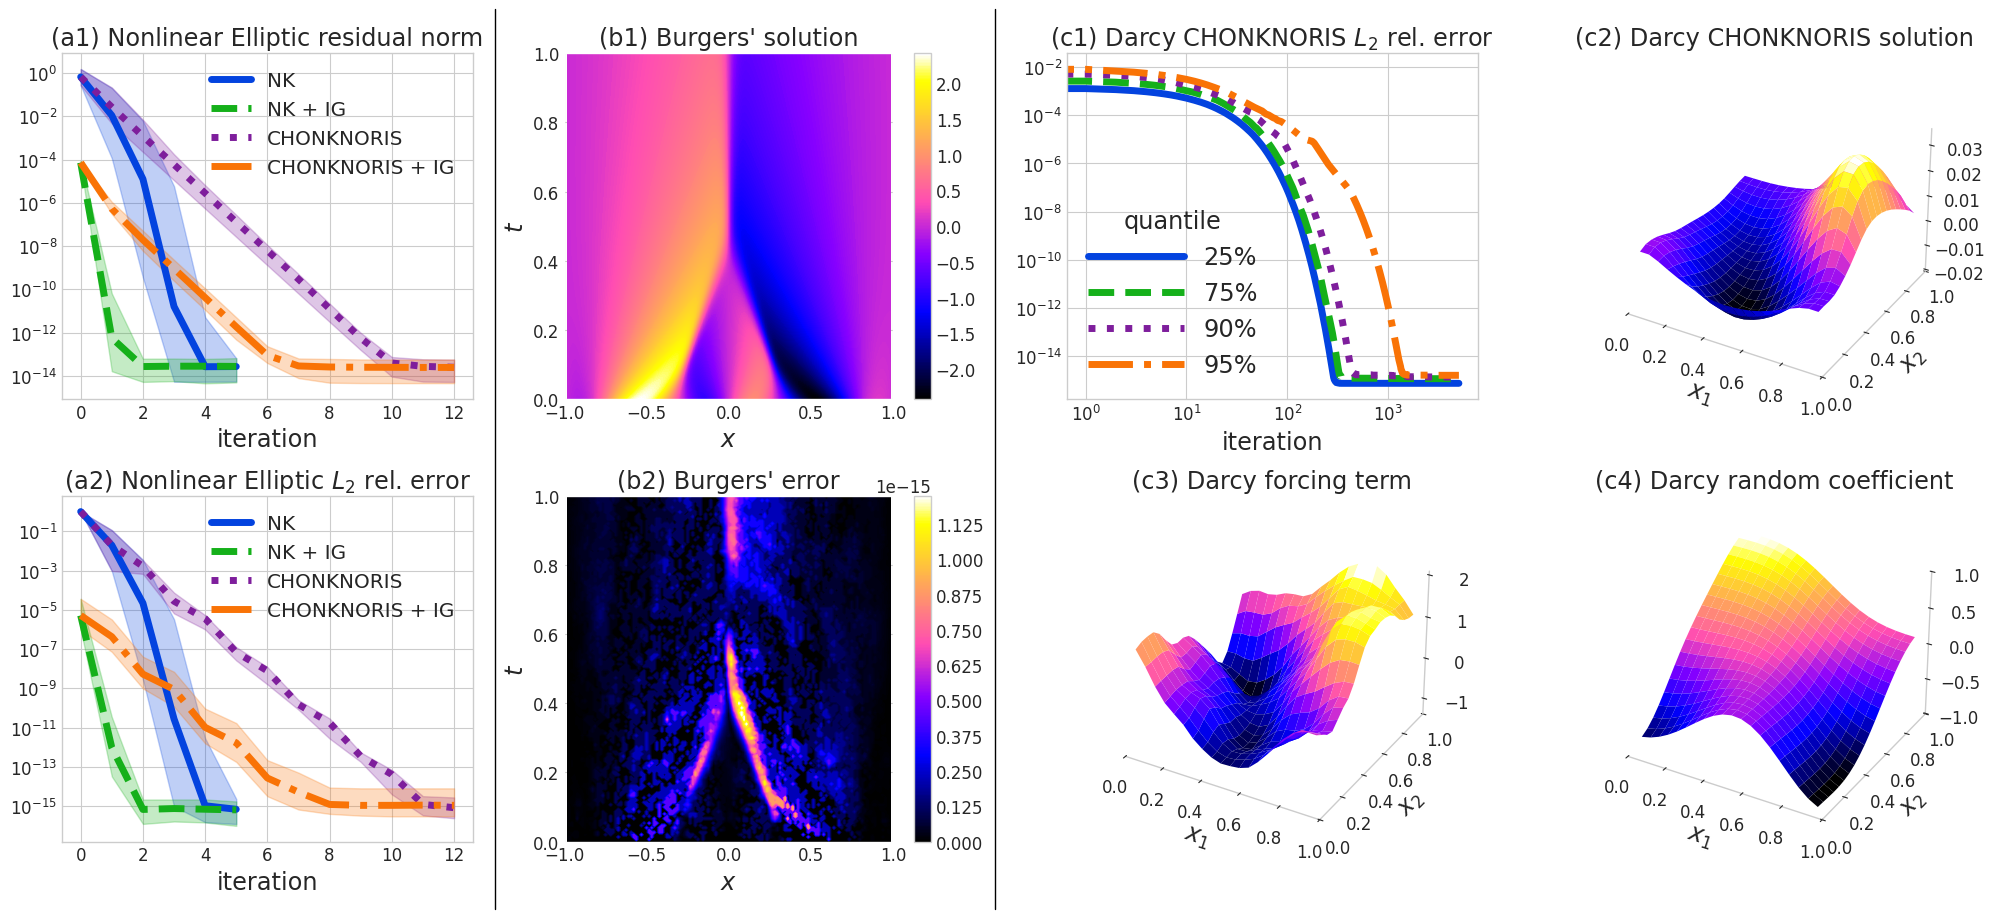

In [10]:
nrows = 2 
ncols = 4
fig = pyplot.figure(figsize=(5*ncols,4.5*nrows))
ax = np.array([[fig.add_subplot(nrows,ncols,i*ncols+j+1,projection=None if (j<2 or (i==0 and j==2)) else "3d") for j in range(ncols)] for i in range(nrows)]).reshape((nrows,ncols))
# ELLIPTIC 1D PDE 
for j,(key,data_Linv) in enumerate(data_Linvs_epde1d.items()):
    for k,metric in enumerate(["rmse_resid","l2rerrors"]):
        medians = torch.quantile(data_Linv[metric],q=0.5,dim=0)
        iterrange = torch.arange(len(medians))
        ax[k,0].plot(iterrange,medians,linewidth=lwthick,color=COLORS[j],label=key.replace("Initial Guess","IG"),linestyle=linestyles[j])
        ax[k,0].fill_between(iterrange,
                        torch.quantile(data_Linv[metric],q=0.1,dim=0),
                        torch.quantile(data_Linv[metric],q=0.9,dim=0),
                        color = COLORS[j], 
                       alpha = 0.25)
for i in range(2):
    ax[i,0].set_yscale("log",base=10)
ax[0,0].set_title("(a1) Nonlinear Elliptic residual norm",fontsize="xx-large")
ax[1,0].set_title("(a2) Nonlinear Elliptic $L_2$ rel. error",fontsize="xx-large")
ax[0,0].set_xlabel(r"iteration",fontsize="xx-large")
ax[1,0].set_xlabel(r"iteration",fontsize="xx-large")
ax[0,0].legend(frameon=False,fontsize="x-large")
ax[1,0].legend(frameon=False,fontsize="x-large")
# BURGERS 
data_Linv = data_Linvs_dpde2d["Fast GPR_lr_0.100000"]
data_ref = data_Linvs_dpde2d["reference"]
data_Linv["vs"].shape,data_ref["vs"].shape
r = 3
cf = ax[0,1].contourf(xmesh_b1d,tmesh_b1d,data_v_chonknoris_b1d["MLP"]["vs"][rfull,:,-1,:],cmap="gnuplot2",levels=250)
fig.colorbar(cf)
cf = ax[1,1].contourf(xmesh_b1d,tmesh_b1d,torch.abs(data_v_nk_b1d["vs"][rfull,:,-1,:]-data_v_chonknoris_b1d["MLP"]["vs"][rfull,:,-1,:]),cmap="gnuplot2",levels=250)
fig.colorbar(cf)
for j in range(2):
    ax[j,1].set_xlim([-1,1])
    ax[j,1].set_ylim([0,1])
    for spine in ["left","top","bottom","right"]:
        ax[j,1].spines[spine].set_color("white")#(False)
    ax[j,1].set_xlabel(r"$x$",fontsize="xx-large")
    ax[j,1].set_ylabel(r"$t$",fontsize="xx-large")
ax[0,1].set_title("(b1) Burgers' solution",fontsize="xx-large")
ax[1,1].set_title("(b2) Burgers' error",fontsize="xx-large")
# DARCY 
qs = [.25,.75,.9,.95]
for i,q in enumerate(qs):
    ax[0,2].plot(torch.arange(data_Linv["l2rerrors"].size(1)),torch.nanquantile(data_Linv["l2rerrors"],q=q,dim=0),linewidth=lwthick,linestyle=linestyles[i],label="%d%%"%(100*q))
ax[0,2].legend(fontsize="xx-large",title="quantile",title_fontsize="xx-large",handlelength=4,frameon=False)
ax[0,2].set_yscale("log",base=10)
ax[0,2].set_xscale("log",base=10)
ax[0,2].set_title("(c1) Darcy CHONKNORIS $L_2$ rel. error",fontsize="xx-large")
ax[1,2].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),f_dpde2d.cpu(),**surfkwargs)
ax[1,3].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),u_v_dpde2d[r,0].cpu(),**surfkwargs)
ax[0,3].plot_surface(x1mesh_dpde2d.cpu(),x2mesh_dpde2d.cpu(),data_ref["vs"][r,-1].cpu(),**surfkwargs)
ax[1,2].set_title("(c3) Darcy forcing term",fontsize="xx-large")
ax[1,3].set_title("(c4) Darcy random coefficient",fontsize="xx-large")
ax[0,3].set_title("(c2) Darcy CHONKNORIS solution",fontsize="xx-large")
for i in range(2):
    for j in range(2,4):
        if i==0 and j==2: continue 
        ax[i,j].set_xlim([0,1])
        ax[i,j].set_ylim([0,1])
        ax[i,j].xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax[i,j].xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
        ax[i,j].yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
        ax[i,j].zaxis._axinfo["grid"]['color'] =  (1,1,1,0) 
        ax[i,j].tick_params(axis='z', which='major', pad=7)
        ax[i,j].set_xlabel(r"$x_1$",fontsize="xx-large")
        ax[i,j].set_ylabel(r"$x_2$",fontsize="xx-large")
ax[0,2].set_xlabel("iteration",fontsize="xx-large")
# META 
fig.tight_layout()
fig.add_artist(pyplot.Line2D((.5,.5),(0,1),linewidth=1,color="k"))
fig.add_artist(pyplot.Line2D((.25,.25),(0,1),linewidth=1,color="k"))
fig.savefig("out/forward_problems_complete.png",bbox_inches="tight",dpi=256,transparent=True)